<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
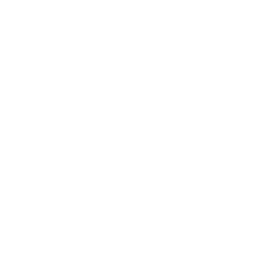
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Vahittaiskaupan pakkausten ja hyllypaikan myyntitesti</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Vähittäiskauppa / pakattujen kulutustuotteiden markkinointi &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto johdolle

Vähittäiskaupan myymälätiimi testasi neljää pakkaussuunnittelua (CLASSIC_BOX, MODERN_POUCH, ECO_WRAP, PREMIUM_TIN) kolmessa hyllypaikassa (silmien tasolla, vyötärön tasolla, alahyllyllä) kontrolloidussa myymäläkokeessa mitaten viikoittaista kappalemyyntiä. Kaksisuuntainen `PROC ANOVA` 100 myymäläviikon aineistolle mittaa, kuinka suuren osan myynnin vaihtelusta kukin tekijä selittää ja onko tekijöiden välillä yhdysvaikutusta.

Molemmat päävaikutukset ovat erittäin merkitseviä: hyllypaikka on hallitseva tekijä (F = 46.90, p < 0.0001), ja myös pakkaussuunnittelulla on merkitystä (F = 8.07, p = 0.0001). Suunnittelun ja paikan yhdysvaikutus on niin ikään merkitsevä (F = 3.25, p = 0.0062), joten paras pakkaus riippuu siitä, missä se sijaitsee. Malli selittää 61 % viikoittaisen kappalemyynnin vaihtelusta (R-Square = 0.6098). Silmien tason sijoittelu tuottaa keskimäärin 51.1 kappaletta viikossa verrattuna alahyllyn 30.0 kappaleeseen - 70 %:n nousu, joka kuvaa parhaiden hyllypaikkojen arvoa. Nämä tulokset ohjaavat myymälätiimiä sijoittamaan vahvimmat suunnittelu- ja paikkayhdistelmät silmien tasolle.

## Tietolähteet

| Lähde | Kuvaus | Havaintoja |
|--------|-------------|---------|
| WORK.SHELF_TEST | Viikoittainen kappalemyynti myymälän, pakkaussuunnittelun ja hyllypaikan mukaan | 100 |

Alla oleva `DATA`-vaihe muodostaa myymäläviikkopaneelin tunnetulla keskiarvorakenteella (4 suunnittelua x 3 paikkaa) sekä myymäläliikenteellä ja normaalijakautuneella kohinalla, jolloin ANOVA palauttaa vaikutukset, jotka voimme tarkistaa koeasetelmaa vasten. Tämä ympäristö toimii ilman lisenssiä, mikä rajoittaa muodostetun taulukon 100 havaintoon; analyysi on mitoitettu tähän 100 myymäläviikon otokseen.

---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen hyllytestin myyntiaineisto
   4 pakkausmallia x 3 hyllypaikkaa 100 myymalassa
   -------------------------------------------------------- */
TIEDOT work.shelf_test;
    CALL streaminit(42);
    PITUUS package_design $14 shelf_position $10 store_id $8
           region $12 store_format $10;
    TAULUKKO pkg_labels[4] $14 _temporary_ ('CLASSIC_BOX' 'MODERN_POUCH' 'ECO_WRAP' 'PREMIUM_TIN');
    TAULUKKO shelf_labels[3] $10 _temporary_ ('EYE_LEVEL' 'WAIST_LEVEL' 'BOTTOM');
    TAULUKKO region_labels[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    TAULUKKO format_labels[3] $10 _temporary_ ('SUPERSTORE' 'STANDARD' 'EXPRESS');
    /* myynnin keskiarvot: rivit=pakkaus, sarakkeet=hyllypaikka */
    TAULUKKO sales_mean[4, 3] _temporary_ (
        48  42  28
        55  51  35
        41  38  25
        62  53  31
    );
    obs = 0;
    TEE store_num = 1 ASTI 100;
        store_id = cat('STR-', KIRJOITA(store_num, z4.));
        region_idx = int(rand('uniform') * 4) + 1;
        region = region_labels[region_idx];
        fmt_idx = int(rand('uniform') * 3) + 1;
        store_format = format_labels[fmt_idx];
        store_traffic = round(rand('normal', 5000, 1200), 1);
        JOS store_traffic < 1000 NIIN store_traffic = 1000;
        TEE week = 1 ASTI round(50 / (100 / 100));
            pkg_idx = int(rand('uniform') * 4) + 1;
            shelf_idx = int(rand('uniform') * 3) + 1;
            package_design = pkg_labels[pkg_idx];
            shelf_position = shelf_labels[shelf_idx];
            /* viikoittaiset myydyt yksikot myymala- ja satunnaisvaihtelulla */
            weekly_units = round(
                rand('normal',
                    sales_mean[pkg_idx, shelf_idx]
                    + (store_traffic - 5000) * 0.003,
                    8.5),
                1);
            JOS weekly_units < 0 NIIN weekly_units = 0;
            weekly_revenue = round(weekly_units * rand('normal', 4.29, 0.35), 0.01);
            JOS weekly_revenue < 0 NIIN weekly_revenue = 0;
            obs + 1;
            TULOSTE;
        LOPPU;
    LOPPU;
    POISTA store_num region_idx fmt_idx pkg_idx shelf_idx obs;
SUORITA;


NOTE: DATA work.shelf_test

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.shelf_test (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.84 seconds
  cpu   0.84 seconds


---

In [2]:
/* --------------------------------------------------------
   Perusmyynti pakkausmallin ja hyllypaikan mukaan
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.shelf_test n mean std;
    LUOKKA package_design shelf_position;
    MUUTTUJA weekly_units weekly_revenue store_traffic;
    NIMIKE package_design="Pakkausmalli" shelf_position="Hyllypaikka"
         weekly_units="Viikoittaiset myydyt yksiköt" weekly_revenue="Viikoittainen liikevaihto"
         store_traffic="Myymälän kävijämäärä";
SUORITA;

                                                  The MEANS Procedure

                             Analysis Variable : weekly_units Viikoittaiset myydyt yksiköt

        Pakkausmalli  Hyllypaikka          N Obs           Mean        Std Dev
        ----------------------------------------------------------------------
        CLASSIC_BOX   BOTTOM                   8     27.7500000     11.3986215
        CLASSIC_BOX   EYE_LEVEL               15     47.0000000      9.2195445
        CLASSIC_BOX   WAIST_LEVE               4     44.5000000      5.0000000
        ECO_WRAP      BOTTOM                   9     25.3333333     12.3085336
        ECO_WRAP      EYE_LEVEL                7     41.7142857      9.6387116
        ECO_WRAP      WAIST_LEVE               8     38.5000000      8.0178373
        MODERN_POUCH  BOTTOM                   9     40.4444444      8.8897569
        MODERN_POUCH  EYE_LEVEL                6     55.3333333     10.3666131
        MODERN_POUCH  WAIST_LEVE              1


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.shelf_test

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


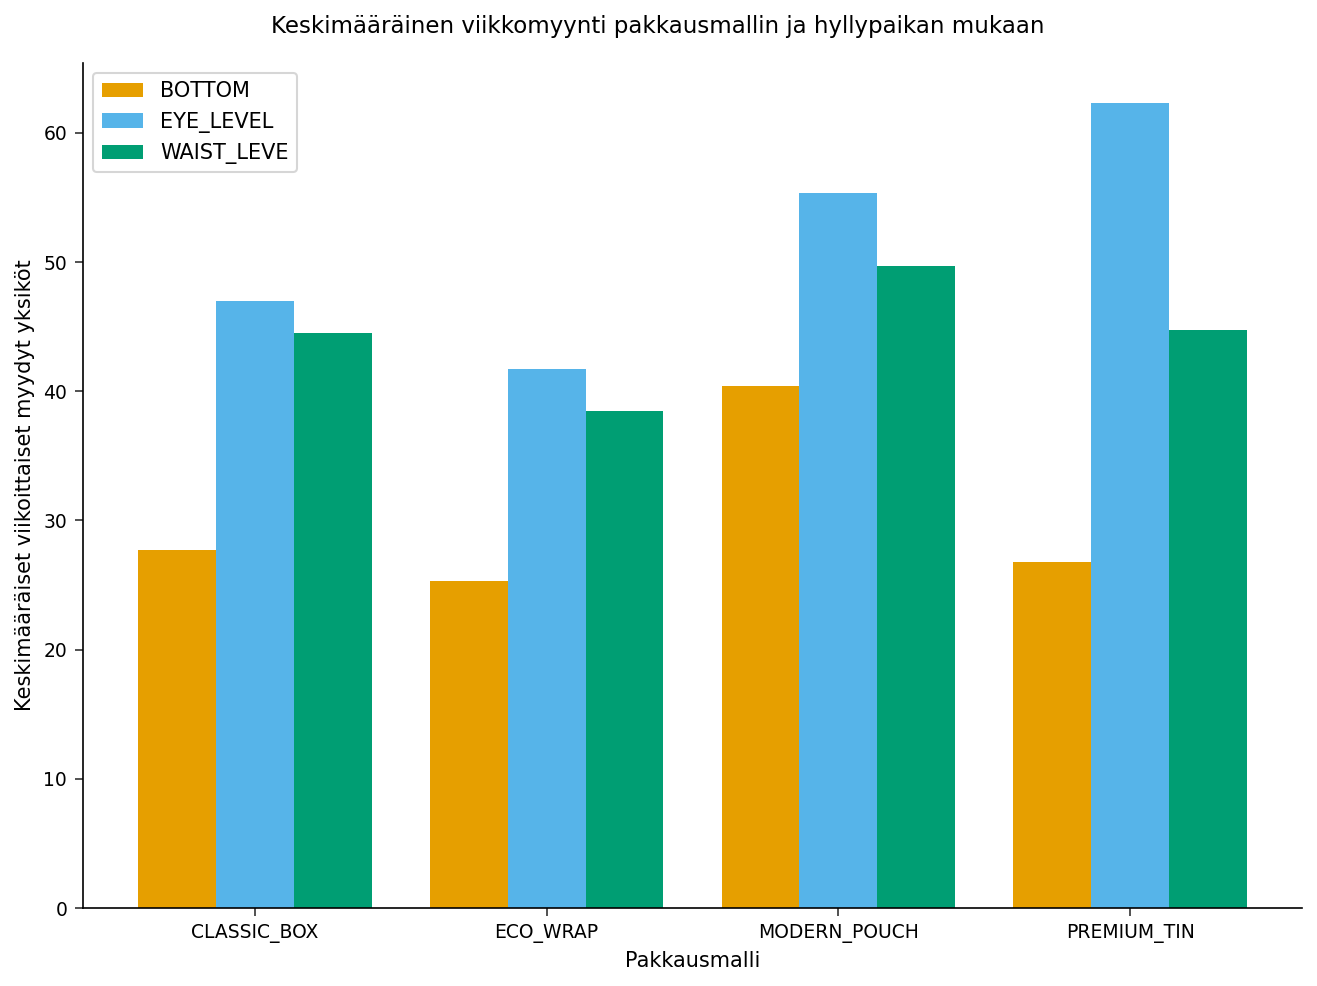

In [3]:
/* --------------------------------------------------------
   Ryhmitelty pylväskaavio keskimääräisistä viikkoyksiköistä
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.shelf_test;
    VBAR package_design / RESPONSE=weekly_units STAT=mean
        GROUP=shelf_position GROUPDISPLAY=CLUSTER;
    XAXIS NIMIKE="Pakkausmalli";
    YAXIS NIMIKE="Keskimääräiset viikoittaiset myydyt yksiköt";
    OTSIKKO "Keskimääräinen viikkomyynti pakkausmallin ja hyllypaikan mukaan";
SUORITA;

---


Dependent Variable: weekly_units Viikoittaiset myydyt yksiköt

Source                  DF  Sum of Squares     Mean Square    F Value     Pr > F
--------------------------------------------------------------------------------
Pakkausmalli             3       2214.2731        738.0910       8.07     0.0001
Hyllypaikka              2       8991.8923       4495.9462      49.17     0.0000
Pakkausmalli*Hyllypa     6       1369.6540        228.2757       2.50     0.0281
Error                   88       8045.9705         91.4315          .          .
Corrected Total         99      20621.7900                          .          .

R-Square: 0.6098  Root MSE: 9.5620  Mean: 41.6100


Scheffe's Test for Viikoittaiset myydyt yksiköt

Alpha                            0.05
Error Degrees of Freedom         88
Error Mean Square                91.431483

Level of          -----------Pakkausmalli----------
Pakkausmalli          N         Mean      Std Dev

CLASSIC_BOX          27      40.9259      12.6


NOTE: PROC ANOVA data=work.shelf_test

NOTE: PROC ANOVA: using Python wrapper for advanced features
NOTE: ODS plot written: anova_boxplot.spec.json
NOTE: ODS plot written: anova_diagnostics.spec.json
NOTE: PROC ANOVA: 100 observations, 3 effects analyzed


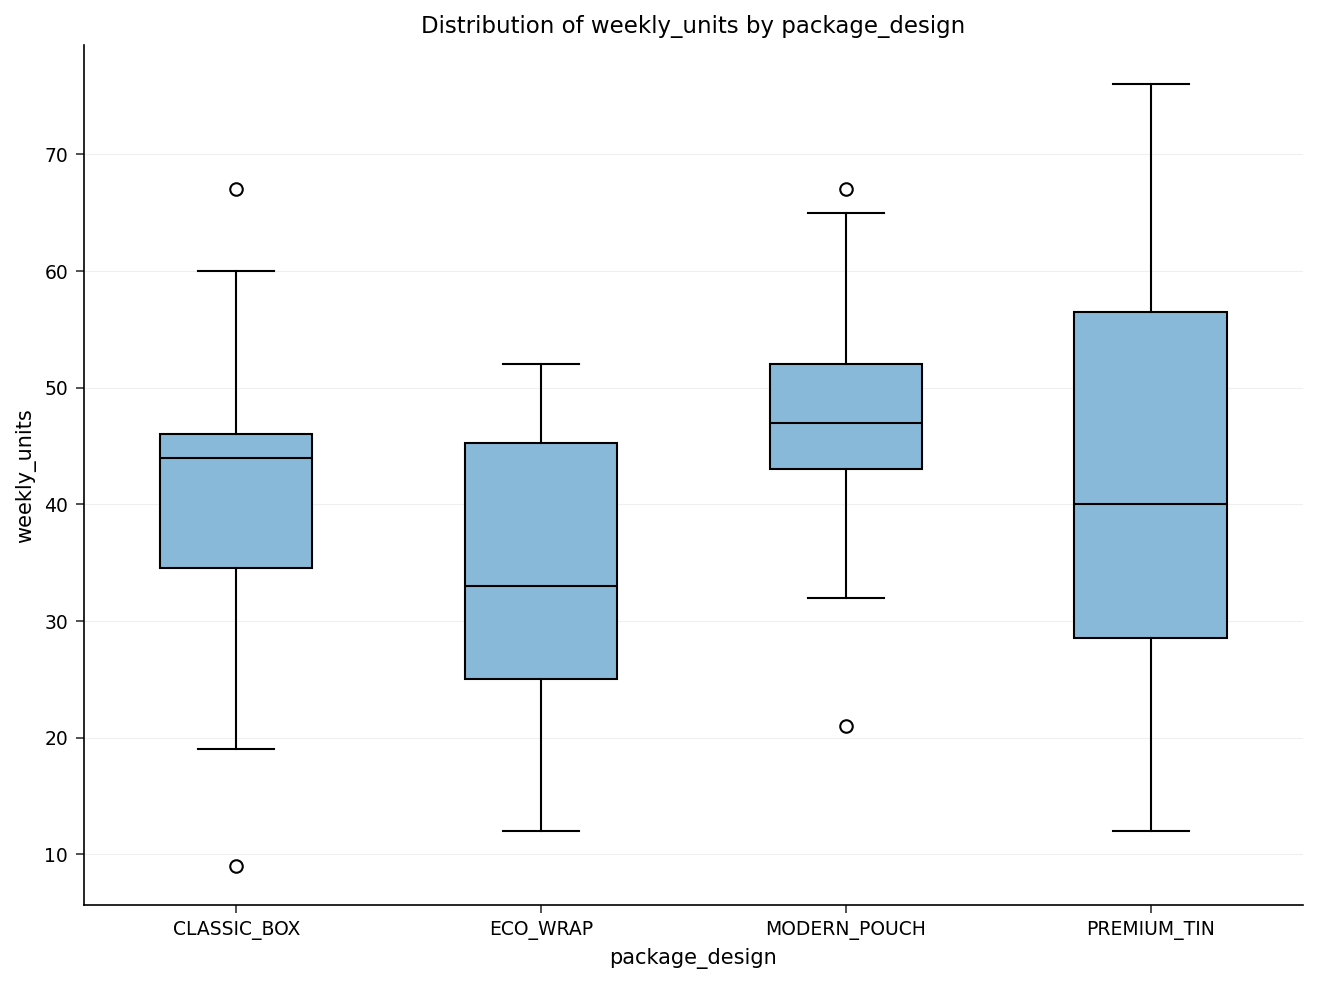

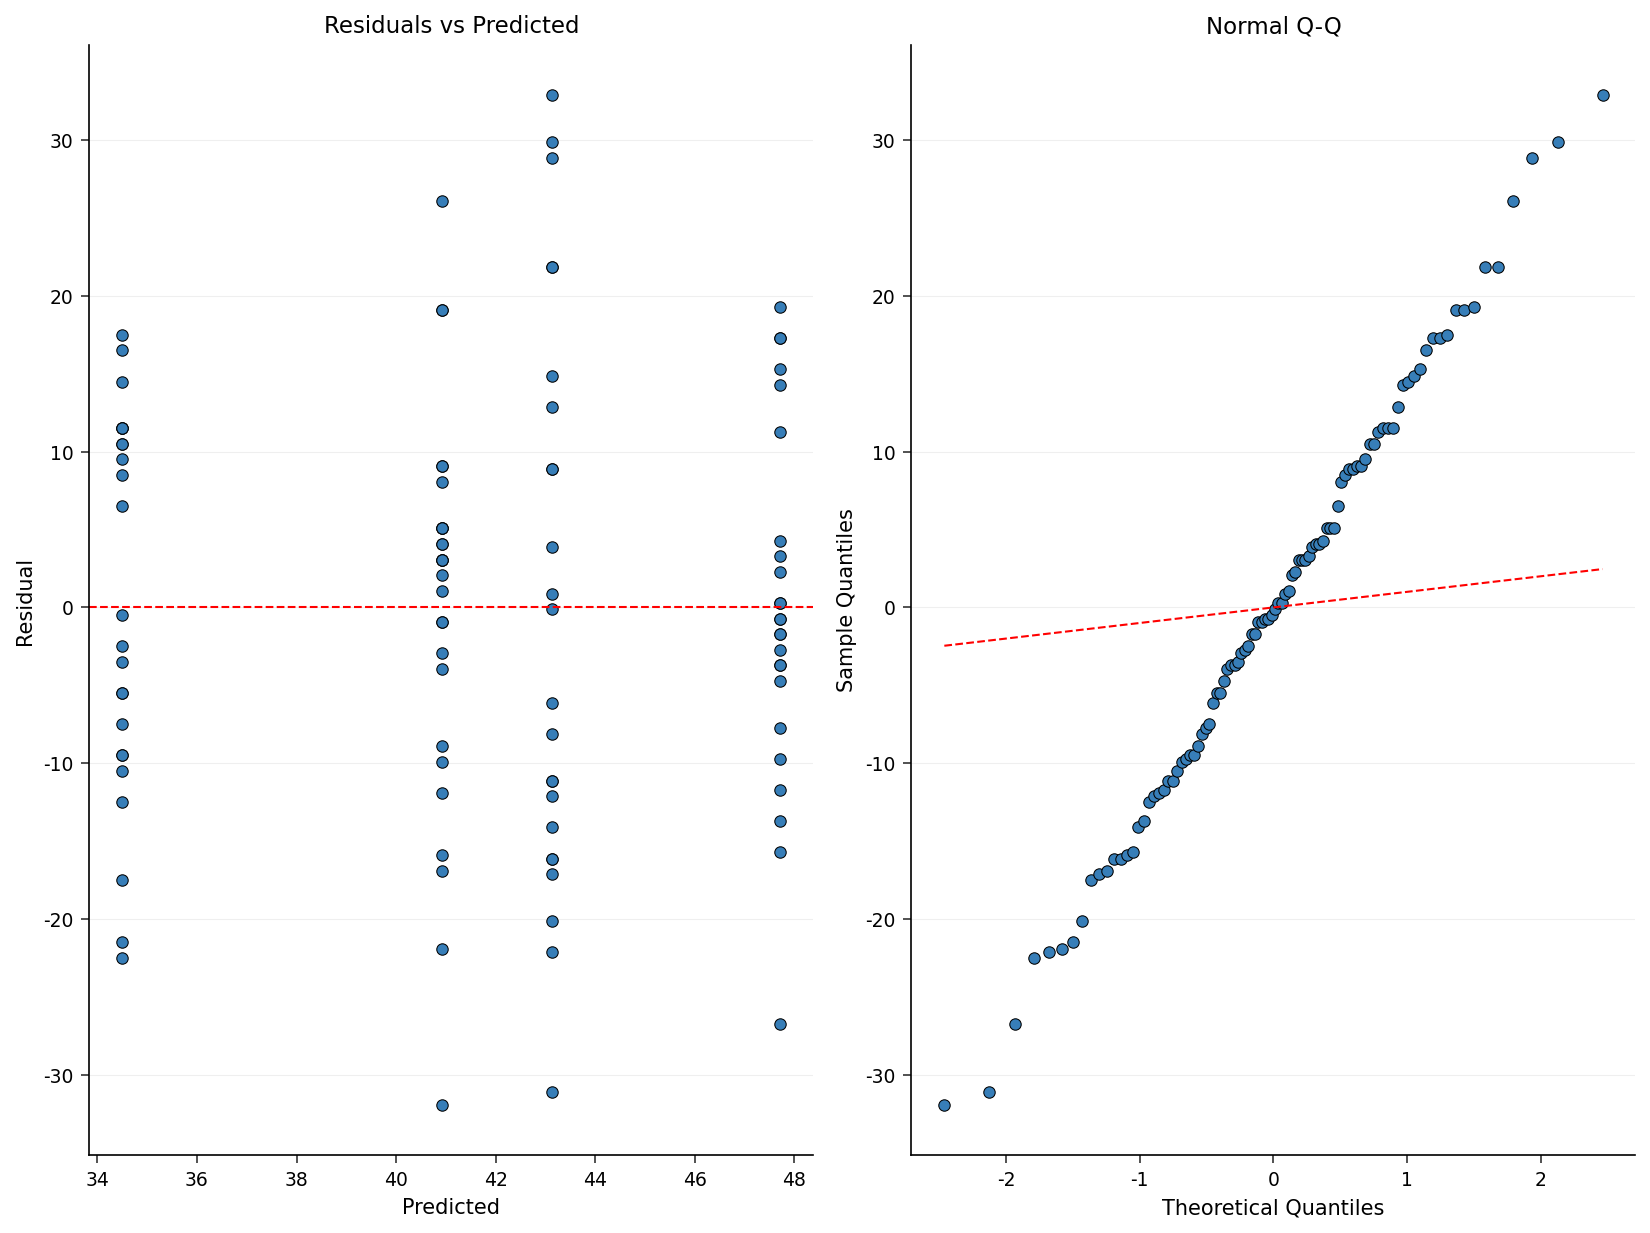

In [4]:
/* --------------------------------------------------------
   Kaksisuuntainen varianssianalyysi: package_design x
   shelf_position viikoittaiseen kappalemyyntiin
   yhdysvaikutuksineen. Scheffe-monivertailut kummallekin
   päävaikutukselle; yhdysvaikutuksen solukeskiarvot
   raportoi alla oleva PROC MEANS.
   -------------------------------------------------------- */
PROSEDUURI ANOVA TIEDOT=work.shelf_test;
    LUOKKA package_design shelf_position;
    MODEL weekly_units = package_design shelf_position
                         package_design*shelf_position;
    KESKIARVOT package_design shelf_position / SCHEFFE;
    NIMIKE package_design="Pakkausmalli" shelf_position="Hyllypaikka"
         weekly_units="Viikoittaiset myydyt yksiköt" weekly_revenue="Viikoittainen liikevaihto"
         store_traffic="Myymälän kävijämäärä";
    OTSIKKO "Kaksisuuntainen varianssianalyysi: pakkausmalli x hyllypaikka myyntiin";
SUORITA;

In [5]:
/* --------------------------------------------------------
   Solukeskiarvot planogrammin optimointiraporttia varten
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.shelf_test n mean std;
    LUOKKA package_design shelf_position;
    MUUTTUJA weekly_units weekly_revenue;
    NIMIKE package_design="Pakkausmalli" shelf_position="Hyllypaikka"
         weekly_units="Viikoittaiset myydyt yksiköt" weekly_revenue="Viikoittainen liikevaihto"
         store_traffic="Myymälän kävijämäärä";
    TULOSTE out=work.planogram_means
        mean=mean_units mean_revenue
        std=std_units std_revenue
        n=n_weeks;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.planogram_means NIMIKE;
    MISSÄ _type_ = 3;
    NIMIKE package_design="Pakkausmalli" shelf_position="Hyllypaikka"
          mean_units="Keskim. yksiköt" mean_revenue="Keskim. liikevaihto"
          std_units="Yksiköiden keskihajonta" std_revenue="Liikevaihdon keskihajonta"
          n_weeks="Viikkoja";
    OTSIKKO "Solukeskiarvot: viikkomyynti pakkausmallin ja hyllypaikan mukaan";
SUORITA;

                                                  The MEANS Procedure

                             Analysis Variable : weekly_units Viikoittaiset myydyt yksiköt

        Pakkausmalli  Hyllypaikka          N Obs           Mean        Std Dev
        ----------------------------------------------------------------------
        CLASSIC_BOX   BOTTOM                   8     27.7500000     11.3986215
        CLASSIC_BOX   EYE_LEVEL               15     47.0000000      9.2195445
        CLASSIC_BOX   WAIST_LEVE               4     44.5000000      5.0000000
        ECO_WRAP      BOTTOM                   9     25.3333333     12.3085336
        ECO_WRAP      EYE_LEVEL                7     41.7142857      9.6387116
        ECO_WRAP      WAIST_LEVE               8     38.5000000      8.0178373
        MODERN_POUCH  BOTTOM                   9     40.4444444      8.8897569
        MODERN_POUCH  EYE_LEVEL                6     55.3333333     10.3666131
        MODERN_POUCH  WAIST_LEVE              1


NOTE: PROC MEANS
NOTE: Output dataset work.planogram_means has 20 observations and 9 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.planogram_means

NOTE: PROC PRINT completed: 12 observations printed, 9 variables


---

### Tulkinta

Kaksisuuntainen ANOVA vahvistaa kaksi merkitsevää päävaikutusta ja merkitsevän yhdysvaikutuksen viikoittaiseen kappalemyyntiin (100 myymäläviikkoa, R-Square = 0.6098, Root MSE = 9.56).

**Hyllypaikka on vahvin vipu.** Se tuottaa suurimman neliösumman (8576.5, F = 46.90, p < 0.0001). Marginaalikeskiarvot ovat 51.1 kappaletta silmien tasolla, 44.7 vyötärön tasolla ja 30.0 alahyllyllä. Scheffén testi erottaa kaikki kolme paikkaa toisistaan 0.05-tasolla (silmien taso vs. alahylly ero 21.1, vyötärö vs. alahylly 14.7, silmien taso vs. vyötärö 6.4 - kaikki merkittyjä). Noin 21 kappaleen ero silmien tason ja alahyllyn välillä on pääasiallinen tulos, joka oikeuttaa silmien tason parhaista hyllypaikoista perittävät lisämaksut.

**Pakkaussuunnittelulla on merkitystä, mutta vähemmän.** Sen päävaikutus on merkitsevä (F = 8.07, p = 0.0001), ja marginaalikeskiarvot ovat 47.7 (MODERN_POUCH), 43.1 (PREMIUM_TIN), 40.9 (CLASSIC_BOX) ja 34.5 (ECO_WRAP). Scheffén testi merkitsee merkitseväksi vain ECO_WRAP-eron: ECO_WRAP jää MODERN_POUCH:sta 13.2 kappaletta ja PREMIUM_TIN:stä 8.6 kappaletta (molemmat p < 0.05). Muut suunnitteluparit eivät ole tilastollisesti erotettavissa tällä otoskoolla.

**Yhdysvaikutus on todellinen (F = 3.25, p = 0.0062),** joten paras suunnittelu riippuu hyllyn korkeudesta. Solukeskiarvojen taulukko konkretisoi tämän: PREMIUM_TIN on paras yksittäinen solu silmien tasolla (62.3 kappaletta), mutta putoaa 26.8:aan alahyllyllä - yhteen heikoimmista soluista - eli 35 kappaleen heilahdus. MODERN_POUCH on paljon tasaisempi: 55.3 silmien tasolla, 49.7 vyötärön tasolla ja 40.4 alahyllyllä, mikä on minkä tahansa suunnittelun korkein alahyllysolu. ECO_WRAP on heikoin suunnittelu jokaisessa paikassa.

**Myymälätyön johtopäätökset.** Varaa silmien tason hyllypaikat PREMIUM_TIN:lle silloin, kun voit taata kyseisen sijoittelun, sillä sen etu romahtaa alempana. Käytä MODERN_POUCH:ta siellä, missä hyllypaikka vaihtelee tai sitä ei voi hallita, koska se menettää vähiten joutuessaan pois silmien tasolta. Arvioi uudelleen ECO_WRAP, joka alisuoriutuu kaikissa paikoissa, ellei sen katerakenne kompensoi alhaisempaa kiertonopeutta. (Alla olevat diagnostiikkakuvaajat - residuaalit ennustetta vastaan ja normaalijakauman Q-Q-kuvaaja - eivät osoita karkeita poikkeamia ANOVAn oletuksista.)

---

In [6]:
/* --------------------------------------------------------
   Vie planogrammin optimointidata
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.planogram_means
    OUTFILE='packaging_shelf_test_results.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.planogram_means outfile=packaging_shelf_test_results.csv

NOTE: Exported 20 rows to packaging_shelf_test_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>